## Chargement des modules

In [257]:
import geopandas as gpd
import pandas as pd
pd.set_option('display.max_columns', 300)
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import cross_val_score
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb
from sklearn.metrics import accuracy_score
from xgboost import callback
import warnings
from IPython.display import FileLink

## Preprocessing

In [ ]:
train_df = gpd.read_file("train.geojson")
test_df = gpd.read_file("test.geojson")

In [ ]:
y_train = train_df['change_type']
X_train = train_df.drop(columns=['change_type'])
X_test = test_df



In [ ]:
X_train.head()

,urban_type,geography_type,img_red_mean_date1,img_green_mean_date1,img_blue_mean_date1,img_red_std_date1,img_green_std_date1,img_blue_std_date1,img_red_mean_date2,img_green_mean_date2,img_blue_mean_date2,img_red_std_date2,img_green_std_date2,img_blue_std_date2,img_red_mean_date3,img_green_mean_date3,img_blue_mean_date3,img_red_std_date3,img_green_std_date3,img_blue_std_date3,img_red_mean_date4,img_green_mean_date4,img_blue_mean_date4,img_red_std_date4,img_green_std_date4,img_blue_std_date4,img_red_mean_date5,img_green_mean_date5,img_blue_mean_date5,img_red_std_date5,img_green_std_date5,img_blue_std_date5,change_status_date0,change_status_date1,change_status_date2,change_status_date3,change_status_date4,index,date0_year,date0_month,date0_day,date0_weekday,date0_elapsed,date1_year,date1_month,date1_day,date1_weekday,date1_elapsed,date2_year,date2_month,date2_day,date2_weekday,date2_elapsed,date3_year,date3_month,date3_day,date3_weekday,date3_elapsed,date4_year,date4_month,date4_day,date4_weekday,date4_elapsed,area,perimeter
0,Sparse Urban,"Dense Forest,Grass Land",93.371775,107.291113,89.827379,29.812040,28.328368,25.324294,125.773062,139.833243,134.900701,28.269984,28.264907,25.008032,150.766726,158.964529,149.356684,55.745311,47.576383,42.723218,92.291347,88.794250,79.570064,39.819949,30.864230,28.189604,104.614233,100.950353,102.844339,33.813160,33.064014,34.818012,Construction Done,Greenland,Construction Started,Construction Done,Construction Midway,0,2018.0,8.0,1.0,2.0,2094.0,2013.0,12.0,9.0,0.0,277.0,2016.0,9.0,10.0,5.0,1975.0,2019.0,7.0,22.0,0.0,3410.0,2017.0,7.0,24.0,0.0,2494.0,8.174601e-07,0.004137
1,Sparse Urban,"Dense Forest,Grass Land",96.071674,107.061702,90.755556,24.896240,22.275180,22.080686,133.097679,145.385190,137.092518,23.683964,21.651242,20.271657,184.480155,186.896779,174.235331,42.130924,38.138137,35.142246,111.001421,102.096357,91.447834,37.129531,28.089549,25.901238,110.445556,103.413826,104.835541,30.670052,33.258905,36.139281,Construction Midway,Greenland,Land Cleared,Construction Done,Construction Midway,1,2018.0,8.0,1.0,2.0,2094.0,2013.0,12.0,9.0,0.0,277.0,2016.0,9.0,10.0,5.0,1975.0,2019.0,7.0,22.0,0.0,3410.0,2017.0,7.0,24.0,0.0,2494.0,4.394334e-07,0.002746
2,Sparse Urban,"Dense Forest,Grass Land",101.212148,113.462178,95.670574,24.179684,21.873401,21.285197,120.713490,131.633447,124.436492,28.951475,25.329365,22.505835,148.150431,158.490141,148.571269,58.434034,48.106798,43.902810,94.519603,91.331925,81.746626,42.510625,33.189102,30.522871,98.734466,97.495577,99.197153,34.436045,33.546000,35.545531,Construction Done,Greenland,Land Cleared,Construction Done,Land Cleared,2,2018.0,8.0,1.0,2.0,2094.0,2013.0,12.0,9.0,0.0,277.0,2016.0,9.0,10.0,5.0,1975.0,2019.0,7.0,22.0,0.0,3410.0,2017.0,7.0,24.0,0.0,2494.0,8.209702e-07,0.004280
3,Rural,"Dense Forest,Grass Land",94.463311,99.995531,84.470046,26.869852,23.767679,19.351983,114.819776,127.827828,120.435373,34.091970,27.963117,23.901639,148.322747,156.855136,148.180798,51.046935,44.444291,40.558345,91.731693,89.100710,79.430155,39.111827,30.762028,28.337671,90.506679,90.076099,92.412922,31.285068,32.613142,36.080342,Construction Midway,Greenland,Construction Started,Construction Done,Construction Midway,3,2018.0,8.0,1.0,2.0,2094.0,2013.0,12.0,9.0,0.0,277.0,2016.0,9.0,10.0,5.0,1975.0,2019.0,7.0,22.0,0.0,3410.0,2017.0,7.0,24.0,0.0,2494.0,8.175168e-07,0.004168
4,Dense Urban,"Sparse Forest,Dense Forest,Farms",151.883646,191.710197,211.569244,52.465332,59.441844,52.304349,141.514462,171.079581,181.960612,24.436771,34.297473,41.600845,170.365008,180.274159,186.818552,32.054249,40.833531,48.325621,108.124000,97.851854,94.141506,27.578335,28.158172,27.306766,155.293576,140.674732,131.007948,40.627077,37.989182,37.177376,Prior Construction,Prior Construction,Prior Construction,Land Cleared,Prior Construction,4,2018.0,8.0,1.0,2.0,2094.0,2013.0,12.0,9.0,0.0,277.0,2016.0,9.0,10.0,5.0,1975.0,2019.0,7.0,22.0,0.0,3410.0,2017.0,7.0,24.0,0.0,2494.0,1.484970e-07,0.001741


In [ ]:
categories = X_train['geography_type'].unique()

print(categories)

['Dense Forest,Grass Land' 'Sparse Forest,Dense Forest,Farms'
 'Sparse Forest,Grass Land,Farms' 'Dense Forest,Farms'
 'Sparse Forest,Farms' 'Sparse Forest,Dense Forest'
 'River,Sparse Forest,Grass Land' 'River,Dense Forest,Farms' 'Coastal'
 'Dense Forest' 'Sparse Forest,Farms,Lakes'
 'River,Sparse Forest,Dense Forest,Farms' 'Sparse Forest,Grass Land'
 'Grass Land' 'Sparse Forest' 'Farms'
 'River,Sparse Forest,Dense Forest,Lakes'
 'Sparse Forest,Dense Forest,Grass Land' 'Farms,Lakes'
 'River,Barren Land,Sparse Forest'
 'Barren Land,Sparse Forest,Dense Forest' 'Barren Land,Sparse Forest'
 'River,Sparse Forest,Farms' 'Sparse Forest,Grass Land,Lakes'
 'Barren Land,Sparse Forest,Dense Forest,Lakes' 'River,Farms'
 'Sparse Forest,Lakes' 'River,Lakes'
 'Barren Land,Sparse Forest,Grass Land'
 'River,Barren Land,Sparse Forest,Dense Forest,Lakes'
 'Barren Land,Sparse Forest,Lakes' 'Barren Land'
 'Sparse Forest,Dense Forest,Lakes'
 'Barren Land,Sparse Forest,Grass Land,Lakes'
 'Sparse Forest,Dense

### Suppression des valeurs NaN

In [ ]:
mask = X_train.notna().all(axis=1) 
X_train = X_train[mask]
y_train = y_train[mask]  

### Encoding

In [ ]:
X_train = pd.get_dummies(X_train, columns=['change_status_date0', 'change_status_date1', 'change_status_date2', 'change_status_date3', 'change_status_date4'])
X_test = pd.get_dummies(X_test, columns=['change_status_date0', 'change_status_date1', 'change_status_date2', 'change_status_date3', 'change_status_date4'])

In [ ]:
X_train = X_train.drop(['geography_type','urban_type'], axis=1)
X_test = X_test.drop(['geography_type','urban_type'], axis=1)

In [ ]:
X_train.shape

(292758, 87)

In [ ]:
y_train.head()

0          Road
1          Road
2          Road
3          Road
4    Demolition
Name: change_type, dtype: object

In [ ]:
n,m = train.shape

NameError: name 'train' is not defined

# NE PAS EXECUTER CETTE PARTIE

### One hot encoding : ça sert pas en fait ça crée beaucoup trop de features qui servent à rien 

Les valeurs des change_status_date sont des valeurs textuelles. On va donc les convertir en valeur numérique en faisant un one hot encoding.

In [ ]:
cat_columns = ["urban_type", "geography_type", 
               "change_status_date0", "change_status_date1", 
               "change_status_date2", "change_status_date3", "change_status_date4"]

# Convertir en string pour éviter les erreurs de type
X_train_cat = X_train[cat_columns].astype(str)
X_test_cat = X_test[cat_columns].astype(str)

# Concaténer train et test avant d'entraîner l'encodeur
full_cat_data = pd.concat([X_train_cat, X_test_cat])

# Initialiser et entraîner l'encodeur sur l'ensemble des données
encoder = OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)
encoder.fit(full_cat_data)

# Appliquer l'encodage sur X_train et X_test
X_train_encoded = pd.DataFrame(encoder.transform(X_train_cat), 
                               columns=encoder.get_feature_names_out(cat_columns),
                               index=X_train.index)

X_test_encoded = pd.DataFrame(encoder.transform(X_test_cat), 
                              columns=encoder.get_feature_names_out(cat_columns),
                              index=X_test.index)


In [ ]:
# Supprimer les colonnes catégoriques d'origine
X_train = X_train.drop(columns=cat_columns)
X_test = X_test.drop(columns=cat_columns)

# Ajouter les nouvelles colonnes encodées
X_train = pd.concat([X_train, X_train_encoded], axis=1)
X_test = pd.concat([X_test, X_test_encoded], axis=1)

# Vérifier la forme finale des DataFrames
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)


X_train shape: (292758, 288)
X_test shape: (120526, 288)
y_train shape: (292758,)


# Dates

In [ ]:
# Identifier les colonnes de type date
date_columns = ["date0", "date1", "date2", "date3", "date4"]

# Convertir en format datetime
for col in date_columns:
    X_train[col] = pd.to_datetime(X_train[col], format="%d-%m-%Y")
    X_test[col] = pd.to_datetime(X_test[col], format="%d-%m-%Y")

# Extraire des features numériques des dates
for col in date_columns:
    X_train[col + "_year"] = X_train[col].dt.year
    X_train[col + "_month"] = X_train[col].dt.month
    X_train[col + "_day"] = X_train[col].dt.day
    X_train[col + "_weekday"] = X_train[col].dt.weekday
    X_train[col + "_elapsed"] = (X_train[col] - X_train[col].min()).dt.days
    
    X_test[col + "_year"] = X_test[col].dt.year
    X_test[col + "_month"] = X_test[col].dt.month
    X_test[col + "_day"] = X_test[col].dt.day
    X_test[col + "_weekday"] = X_test[col].dt.weekday
    X_test[col + "_elapsed"] = (X_test[col] - X_test[col].min()).dt.days

# Supprimer les colonnes de dates originales
X_train = X_train.drop(columns=date_columns)
X_test = X_test.drop(columns=date_columns)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)


X_train shape: (292758, 107)
X_test shape: (120526, 107)
y_train shape: (292758,)


In [ ]:
X_test['area'] = X_test['geometry'].apply(lambda x: x.area)
X_test['perimeter'] = X_test['geometry'].apply(lambda x: x.length)
X_train['area'] = X_train['geometry'].apply(lambda x: x.area)
X_train['perimeter'] = X_train['geometry'].apply(lambda x: x.length)

X_train = X_train.drop(columns=['geometry'])
X_test = X_test.drop(columns=['geometry'])

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)

X_train shape: (292758, 108)
X_test shape: (120526, 108)
y_train shape: (292758,)


In [ ]:
X_test.head()

,img_red_mean_date1,img_green_mean_date1,img_blue_mean_date1,img_red_std_date1,img_green_std_date1,img_blue_std_date1,img_red_mean_date2,img_green_mean_date2,img_blue_mean_date2,img_red_std_date2,img_green_std_date2,img_blue_std_date2,img_red_mean_date3,img_green_mean_date3,img_blue_mean_date3,img_red_std_date3,img_green_std_date3,img_blue_std_date3,img_red_mean_date4,img_green_mean_date4,img_blue_mean_date4,img_red_std_date4,img_green_std_date4,img_blue_std_date4,img_red_mean_date5,img_green_mean_date5,img_blue_mean_date5,img_red_std_date5,img_green_std_date5,img_blue_std_date5,index,date0_year,date0_month,date0_day,date0_weekday,date0_elapsed,date1_year,date1_month,date1_day,date1_weekday,date1_elapsed,date2_year,date2_month,date2_day,date2_weekday,date2_elapsed,date3_year,date3_month,date3_day,date3_weekday,date3_elapsed,date4_year,date4_month,date4_day,date4_weekday,date4_elapsed,change_status_date0_Construction Done,change_status_date0_Construction Midway,change_status_date0_Construction Started,change_status_date0_Excavation,change_status_date0_Greenland,change_status_date0_Land Cleared,change_status_date0_Materials Dumped,change_status_date0_Materials Introduced,change_status_date0_Operational,change_status_date0_Prior Construction,change_status_date1_Construction Done,change_status_date1_Construction Midway,change_status_date1_Construction Started,change_status_date1_Excavation,change_status_date1_Greenland,change_status_date1_Land Cleared,change_status_date1_Materials Dumped,change_status_date1_Materials Introduced,change_status_date1_Operational,change_status_date1_Prior Construction,change_status_date2_Construction Done,change_status_date2_Construction Midway,change_status_date2_Construction Started,change_status_date2_Excavation,change_status_date2_Greenland,change_status_date2_Land Cleared,change_status_date2_Materials Dumped,change_status_date2_Materials Introduced,change_status_date2_Operational,change_status_date2_Prior Construction,change_status_date3_Construction Done,change_status_date3_Construction Midway,change_status_date3_Construction Started,change_status_date3_Excavation,change_status_date3_Greenland,change_status_date3_Land Cleared,change_status_date3_Materials Dumped,change_status_date3_Materials Introduced,change_status_date3_Operational,change_status_date3_Prior Construction,change_status_date4_Construction Done,change_status_date4_Construction Midway,change_status_date4_Construction Started,change_status_date4_Excavation,change_status_date4_Greenland,change_status_date4_Land Cleared,change_status_date4_Materials Dumped,change_status_date4_Materials Introduced,change_status_date4_Operational,change_status_date4_Prior Construction,area,perimeter
0,203.333944,169.801486,152.200651,15.566236,16.008455,17.248278,187.051282,158.300672,140.517298,24.176292,22.166941,22.843903,194.900285,158.205433,136.564611,29.425890,27.236229,25.622538,206.234127,160.040090,143.072039,26.200520,24.249454,23.076722,199.281848,160.665649,144.439153,31.209412,27.944901,27.719833,0,2020.0,7.0,6.0,0.0,2835.0,2014.0,3.0,9.0,6.0,667.0,2016.0,10.0,12.0,2.0,1035.0,2019.0,7.0,18.0,3.0,3406.0,2018.0,2.0,20.0,1.0,2156.0,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,1.017644e-07,0.001293
1,172.061525,147.685474,133.694478,41.475540,44.100325,45.832053,155.780912,135.136855,121.112545,42.975509,45.455919,46.561138,159.233193,126.860744,109.391957,61.307663,51.518197,44.706795,203.666567,154.976591,141.508703,23.220371,24.229261,23.222583,203.359544,163.401561,147.293217,26.396990,23.630056,22.932155,1,2020.0,7.0,6.0,0.0,2835.0,2014.0,3.0,9.0,6.0,667.0,2016.0,10.0,12.0,2.0,1035.0,2019.0,7.0,18.0,3.0,3406.0,2018.0,2.0,20.0,1.0,2156.0,True,False,False,False,False,False,False,False,False,Fals

k = 20 -> Accuracy moyenne: 0.3331
k = 40 -> Accuracy moyenne: 0.4444
k = 60 -> Accuracy moyenne: 0.4956
k = 80 -> Accuracy moyenne: 0.5121
k = 100 -> Accuracy moyenne: 0.5013
k = 120 -> Accuracy moyenne: 0.4868
k = 140 -> Accuracy moyenne: 0.4972
k = 160 -> Accuracy moyenne: 0.5086
k = 180 -> Accuracy moyenne: 0.5008
k = 200 -> Accuracy moyenne: 0.5052
k = 220 -> Accuracy moyenne: 0.5030
k = 240 -> Accuracy moyenne: 0.4989
k = 260 -> Accuracy moyenne: 0.5063
k = 280 -> Accuracy moyenne: 0.5016
k = 300 -> Accuracy moyenne: 0.4955
k = 309 -> Accuracy moyenne: 0.4907


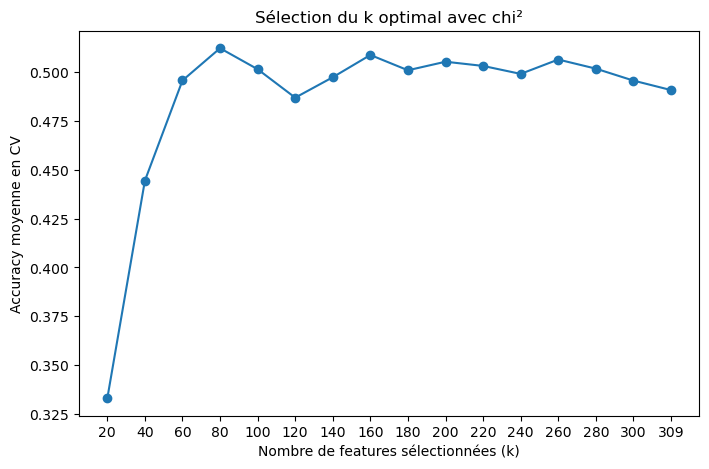

In [ ]:
k_values = [20, 40, 60, 80, 100, 120, 140, 160, 180, 200, 220, 240, 260,280,300,309]
scores = []

for k in k_values:
    
    selector = SelectKBest(score_func=chi2, k=k)
    
    pipeline = Pipeline([
        ('feature_selection', selector),
        ('classification', RandomForestClassifier(random_state=0))
    ])
    
    cv_scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring='accuracy')
    scores.append(np.mean(cv_scores))
    print(f"k = {k} -> Accuracy moyenne: {np.mean(cv_scores):.4f}")

plt.figure(figsize=(8, 5))
plt.plot([str(k) for k in k_values], scores, marker='o')
plt.xlabel('Nombre de features sélectionnées (k)')
plt.ylabel('Accuracy moyenne en CV')
plt.title('Sélection du k optimal avec chi²')
plt.show()

Résultats pas assez satisfaisants et très lents dûs à la taille de notre dataset. 
D'autres modèles peuvent être plus adaptés.

# XGBoost

In [ ]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


### Encodage de y_train

In [ ]:



category_mapping = {
    'Demolition': 0,
    'Road': 1,
    'Residential': 2,
    'Commercial': 3,
    'Industrial': 4,
    'Mega Projects': 5
}


y_train = y_train.map(category_mapping)
y_train

0         1
1         1
2         1
3         1
4         0
         ..
296141    3
296142    2
296143    2
296144    2
296145    2
Name: change_type, Length: 292758, dtype: int64

In [ ]:
y_train.shape

(292758,)

### Optimisation mémoire

In [ ]:
def reduce_memory_usage(df):
    for col in df.columns:
        if df[col].dtype == "int64":
            df[col] = df[col].astype("int32")
        elif df[col].dtype == "float64":
            df[col] = df[col].astype("float32")
    return df

X_train = reduce_memory_usage(X_train)
X_test = reduce_memory_usage(X_test)

### Paramètres à optimiser

In [ ]:
param_dist = {
    'n_estimators': [100, 200, 300, 400, 500],
    'max_depth': [3, 5, 7, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.2, 0.3],
    'subsample': [0.6, 0.7, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 1.0],
    'gamma': [0, 0.1, 0.3, 0.5, 1],
    'tree_method': ['hist']  
}

### Modèle XGBoost

In [ ]:
warnings.filterwarnings('ignore', category=UserWarning, module='xgboost')

xgb_clf = xgb.XGBClassifier(
    random_state=0,
    eval_metric='merror',
    use_label_encoder=False
)

In [ ]:
y_train

0         1
1         1
2         1
3         1
4         0
         ..
296141    3
296142    2
296143    2
296144    2
296145    2
Name: change_type, Length: 292758, dtype: int64

### Randomized search

In [ ]:
search = RandomizedSearchCV(
    xgb_clf,
    param_distributions=param_dist,
    n_iter=50,
    cv = 5,
    scoring='accuracy',
    random_state=0,
    verbose=1,
    n_jobs=-1
)

search.fit(X_train, y_train, eval_set=[(X_train, y_train)], verbose=True)

In [ ]:
X_test = X_test[X_train.columns]
y_pred_test = search.best_estimator_.predict(X_test)

print("Meilleurs paramètres :", search.best_params_)
print("Prédictions sur X_test effectuées !")

Meilleurs paramètres : {'tree_method': 'hist', 'subsample': 0.6, 'n_estimators': 400, 'max_depth': 3, 'learning_rate': 0.3, 'gamma': 0.1, 'colsample_bytree': 0.7}
Prédictions sur X_test effectuées !


### Importance des features

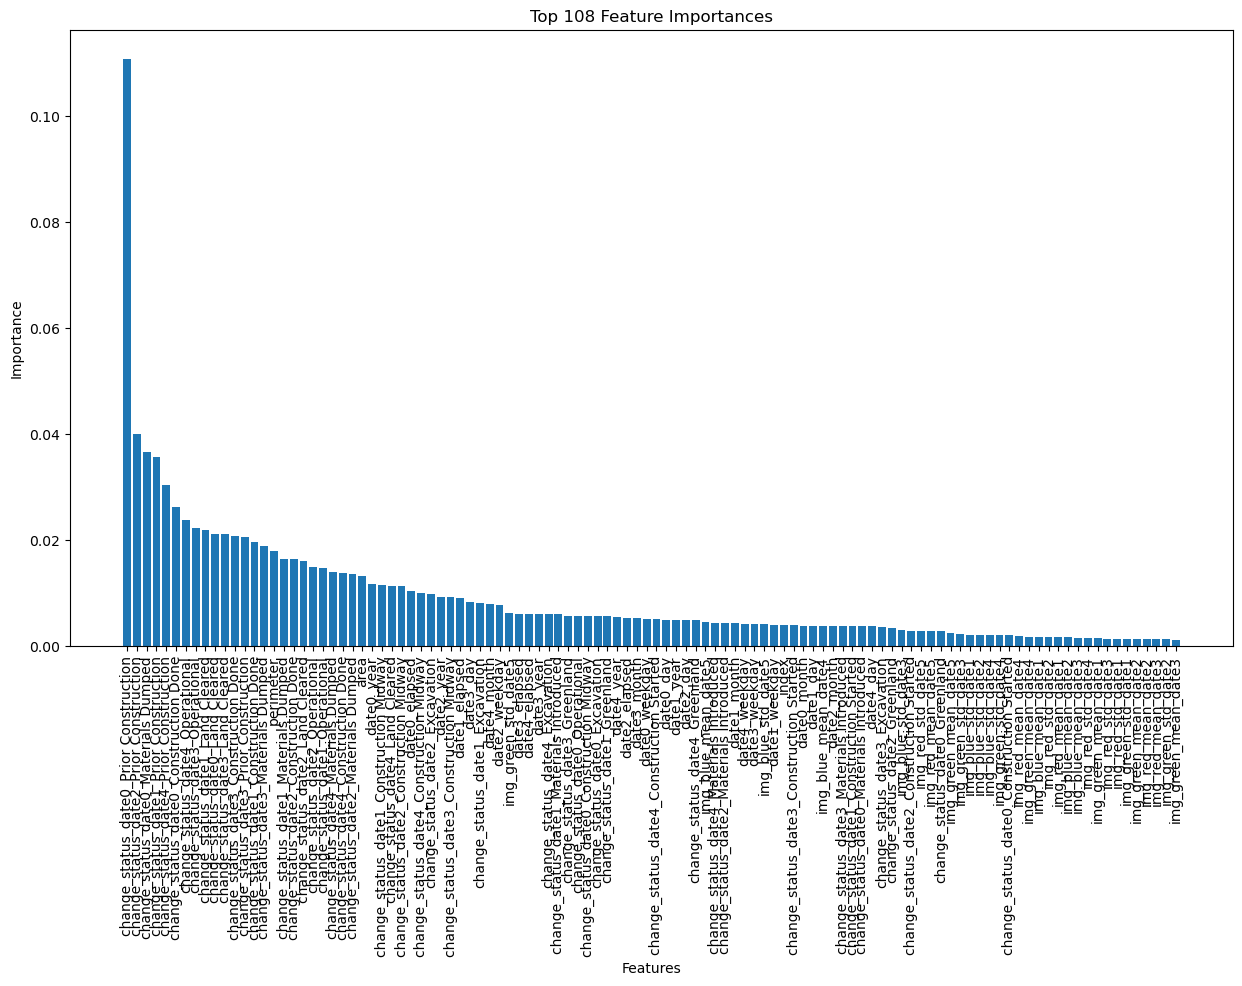

In [ ]:
importances = best_model.feature_importances_
sorted_indices = importances.argsort()[::-1]  


top_108_features = X_train.columns[sorted_indices[:108]]


import matplotlib.pyplot as plt

plt.figure(figsize=(15, 8))
plt.title("Top 108 Feature Importances")
plt.bar(range(108), importances[sorted_indices[:108]], align="center")
plt.xticks(range(108), top_108_features, rotation=90)
plt.xlabel("Features")
plt.ylabel("Importance")
plt.show()


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


importances = best_model.feature_importances_
sorted_indices = importances.argsort()[::-1]  


sorted_importances = importances[sorted_indices]
sorted_features = X_train.columns[sorted_indices]


cumulative_importance = np.cumsum(sorted_importances)


num_features_95 = np.argmax(cumulative_importance >= 0.95) + 1  


top_features_95 = sorted_features[:num_features_95]

print(f"Nombre de features retenues pour 95% d'importance cumulée : {num_features_95}")

Nombre de features retenues pour 95% d'importance cumulée : 81


In [ ]:
X_train_top = X_train[top_features_95]
X_test_top = X_test[top_features_95]

### Prédiction

In [ ]:
best_model = search.best_estimator_
y_pred_test = best_model.predict(X_test)

df_submission = pd.DataFrame({
    'Id': X_test['index'], 
    'Prediction': y_pred_test  
})
df_submission.to_csv('submission.csv', index=False)

In [ ]:
df.head()

,prediction
0,3
1,2
2,2
3,3
4,3


### Téléchargement du fichier csv

In [ ]:
FileLink("submission.csv")

/Users/theophilelahaussois/Competition kaggle/submission.csv

In [ ]:
y_pred_test

array([3, 2, 2, ..., 3, 3, 3])

On arrive à un résultat de 62%, essayons d'améliorer cela

### Amélioration de notre XGBoost

On régularise avec des paramètres alpha et beta dans le module optuna pour éviter l'overfitting